<a href="https://colab.research.google.com/github/Ar7urF1gueired0/calculo_numerico/blob/main/Atividade_II_CN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Atividade Prática II - Cálculo Numérico: Estabilidade e Overflow

Este notebook contém a resolução da simulação simplificada de dinâmica dos fluidos computacional, analisando a relação entre estabilidade numérica, passo de tempo e ocorrência de overflow.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

def simular(dt, tipo=np.float32, passos=2000, pontos=21):
    """Simula difusao de velocidade e detecta falhas."""
    H = 0.01
    nu = 1e-4
    y = np.linspace(0, H, pontos)
    dy = H / (pontos - 1)

    r = tipo(nu * dt / dy**2)
    dois = tipo(2)

    u = np.zeros(pontos, dtype=tipo)
    u[0] = tipo(1)

    tempos = [0.0]
    maximos = [float(np.max(np.abs(u)))]
    falha = None

    with np.errstate(over="raise", invalid="raise"):
        for passo in range(1, passos + 1):
            try:
                novo = u.copy()
                novo[1:-1] = (
                    u[1:-1]
                    + r * (
                        u[2:] - dois * u[1:-1] + u[:-2]
                    )
                )
            except FloatingPointError as erro:
                falha = passo
                print(
                    f"dt={dt}, {tipo.__name__}: "
                    f"falha no passo {passo}, "
                    f"t={passo * dt:.4f} s, {erro}"
                )
                break
            u = novo
            tempos.append(passo * dt)
            maximos.append(float(np.max(np.abs(u))))

    if falha is None:
        print(
            f"dt={dt}, {tipo.__name__}: "
            f"{passos} passos sem overflow."
        )

    return {
        "y": y,
        "u": u,
        "tempos": tempos,
        "maximos": maximos,
        "r": float(r),
        "falha": falha,
    }

Maior float32: 3.4028235e+38
Maior float64: 1.7976931348623157e+308
dt=0.001, float32: 2000 passos sem overflow.
dt=0.002, float32: falha no passo 121, t=0.2420 s, overflow encountered in subtract
dt=0.001, float64: 2000 passos sem overflow.
dt=0.002, float64: falha no passo 917, t=1.8340 s, overflow encountered in add


,Tipo Numérico,Passo de Tempo (dt),Valor de r,Ocorrência de Overflow,Iteração da Falha
0,float32,0.001,0.4,Não,-
1,float32,0.002,0.8,Sim,121
2,float64,0.001,0.4,Não,-
3,float64,0.002,0.8,Sim,917


/usr/local/lib/python3.13/dist-packages/matplotlib/scale.py:253: RuntimeWarning: overflow encountered in power
  return np.power(self.base, values)


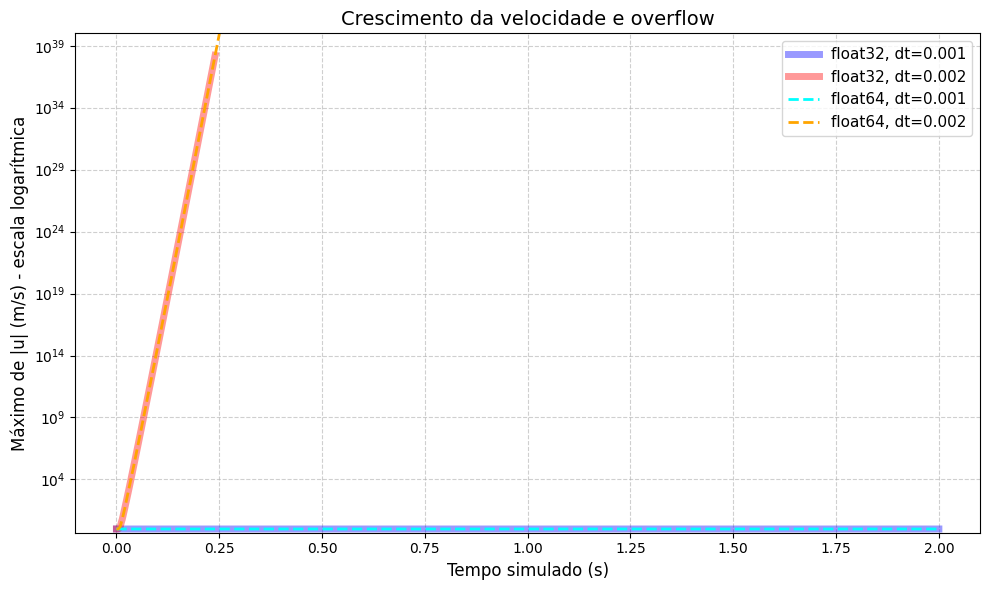

In [7]:
print("Maior float32:", np.finfo(np.float32).max)
print("Maior float64:", np.finfo(np.float64).max)

resultados = {}
tabela_dados = []

# Execução dos 4 testes (combinação de tipos e passos de tempo)
for tipo in (np.float32, np.float64):
    for dt in (0.001, 0.002):
        nome = f"{tipo.__name__}, dt={dt}"
        res = simular(dt, tipo)
        resultados[nome] = res

        # Guardando dados para a tabela da Atividade 2
        teve_overflow = "Sim" if res["falha"] is not None else "Não"
        iteracao_falha = res["falha"] if res["falha"] is not None else "-"
        tabela_dados.append({
            "Tipo Numérico": tipo.__name__,
            "Passo de Tempo (dt)": dt,
            "Valor de r": res["r"],
            "Ocorrência de Overflow": teve_overflow,
            "Iteração da Falha": iteracao_falha
        })

# Exibindo a Tabela da Atividade 2
df_tabela = pd.DataFrame(tabela_dados)
display(df_tabela)

# Gráfico da Atividade 3 - VERSÃO MELHORADA
plt.figure(figsize=(10, 6))

# Dicionário de estilos para diferenciar curvas sobrepostas
estilos = {
    "float32, dt=0.001": {"cor": "blue", "ls": "-", "lw": 5, "alpha": 0.4},  # Linha grossa e translúcida
    "float64, dt=0.001": {"cor": "cyan", "ls": "--", "lw": 2, "alpha": 1.0}, # Linha tracejada por cima
    "float32, dt=0.002": {"cor": "red", "ls": "-", "lw": 5, "alpha": 0.4},   # Linha grossa e translúcida
    "float64, dt=0.002": {"cor": "orange", "ls": "--", "lw": 2, "alpha": 1.0}# Linha tracejada por cima
}

for nome, resultado in resultados.items():
    plt.semilogy(
        resultado["tempos"],
        resultado["maximos"],
        label=nome,
        color=estilos[nome]["cor"],
        linestyle=estilos[nome]["ls"],
        linewidth=estilos[nome]["lw"],
        alpha=estilos[nome]["alpha"]
    )

plt.xlabel("Tempo simulado (s)", fontsize=12)
plt.ylabel("Máximo de |u| (m/s) - escala logarítmica", fontsize=12)
plt.title("Crescimento da velocidade e overflow", fontsize=14)
plt.grid(True, which="both", ls="--", alpha=0.6)
plt.legend(fontsize=11)

# O segredo para a legibilidade: cortar o eixo Y no limite do float32 (aprox 10^38)
# Assim evitamos que o float64 (10^308) esprema todo o gráfico.
plt.ylim(0.5, 1e40)

plt.tight_layout()
plt.show()

### Respostas das Atividades 1, 3 e 4

**1. Verificação da estabilidade:**
*   **Dados:** $H = 0,01$ m, $\nu = 10^{-4} m^2/s$, $pontos = 21$.
*   **Espaçamento ($\Delta y$):** $\Delta y = \frac{H}{(pontos - 1)} = \frac{0,01}{20} = 0,0005$ m.
*   **Limite de estabilidade ($\Delta t_{max}$):** $\Delta t \le \frac{\Delta y^2}{2\nu}$. Logo, $\Delta t_{max} = \frac{(0,0005)^2}{2 \times 10^{-4}} = 0,00125$ s.
*   **Caso A ($\Delta t = 0,001$ s):** $r = \frac{10^{-4} \times 0,001}{(0,0005)^2} = 0,4$. Como $r \le 0,5$, o caso é **Estável**.
*   **Caso B ($\Delta t = 0,002$ s):** $r = \frac{10^{-4} \times 0,002}{(0,0005)^2} = 0,8$. Como $r > 0,5$, o caso é **Instável**.

**3. Interpretação física:**
Conforme o documento, a velocidade física real do fluido deve permanecer no intervalo $0 \le u(y,t) \le U$, ou seja, entre 0 e 1 m/s. O crescimento exponencial observado nos casos instáveis (onde $\Delta t = 0,002$) não representa o comportamento físico porque a velocidade ultrapassa de forma absurda a velocidade máxima do sistema estipulada pelas condições de contorno (placa móvel a 1 m/s e placa fixa a 0 m/s). A viscosidade apenas transmite a velocidade e dissipa energia, ela não pode gerar velocidades maiores do que a velocidade imposta pelas fronteiras.

**4. Capacidade de representação:**
A mudança de `float32` para `float64` **não** elimina a instabilidade. A instabilidade numérica é um problema matemático causado pelo método utilizado quando $r > 1/2$, que permite que oscilações cresçam. O `float64` apenas atrasa a ocorrência do *overflow* no programa. O `float64` possui um limite máximo representável muito maior ($\approx 1,8 \times 10^{308}$) se comparado ao `float32` ($\approx 3,4 \times 10^{38}$). Por isso, a falha (overflow) demora mais passos (iterações) para ocorrer no `float64`, pois as oscilações numéricas precisam de mais tempo crescendo exponencialmente até romper essa barreira superior.

In [6]:
print("--- Teste com Malha Refinada (41 pontos) ---")

H = 0.01
nu = 1e-4
novos_pontos = 41
novo_dy = H / (novos_pontos - 1)
novo_dt_max = (novo_dy**2) / (2 * nu)

print(f"Novo espaçamento (dy): {novo_dy:.5f} m")
print(f"Novo limite de estabilidade (dt_max): {novo_dt_max:.6f} s")

print("\nExecutando com dt antigo (0.001 s):")
res_refinado_instavel = simular(dt=0.001, passos=500, pontos=novos_pontos)

novo_dt_estavel = 0.0002
print(f"\nExecutando com novo dt estavel ({novo_dt_estavel} s):")
res_refinado_estavel = simular(dt=novo_dt_estavel, passos=5000, pontos=novos_pontos)

--- Teste com Malha Refinada (41 pontos) ---
Novo espaçamento (dy): 0.00025 m
Novo limite de estabilidade (dt_max): 0.000312 s

Executando com dt antigo (0.001 s):
dt=0.001, float32: falha no passo 56, t=0.0560 s, overflow encountered in multiply

Executando com novo dt estavel (0.0002 s):
dt=0.0002, float32: 5000 passos sem overflow.


### Resposta da Atividade 5 (Refinamento da malha)
Ao dobrarmos o número de intervalos (passando de 21 para 41 pontos), o $\Delta y$ caiu pela metade, passando para 0,00025 m.
Como o limite de estabilidade depende de $\Delta y^2$, o novo $\Delta t_{max}$ caiu 4 vezes, passando a ser 0,0003125 s.
Ao rodar com $\Delta t = 0,001$ s, o fator $r$ tornou-se maior que 0,5, provocando instabilidade e overflow. O problema foi corrigido rodando com um $\Delta t$ menor (0,0002 s).

dt=0.001, float32: 10000 passos sem overflow.


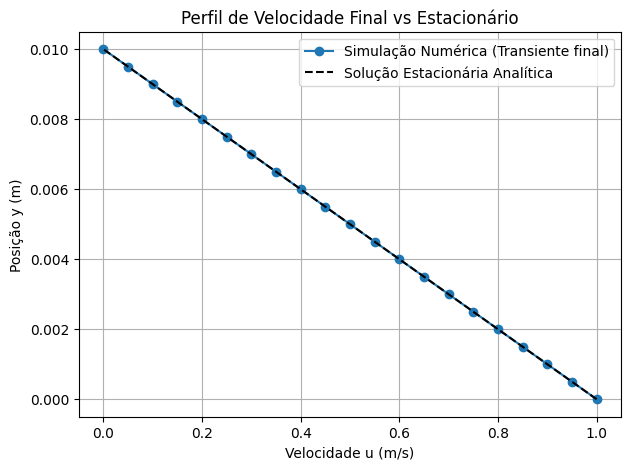

Erro máximo em relação ao perfil estacionário (E_infinito): 2.074242e-06


In [5]:
U = 1.0
H = 0.01

res_final = simular(dt=0.001, passos=10000, pontos=21)
u_simulado = res_final["u"]
y = res_final["y"]

u_estacionario = U * (1 - y/H)

E_infinito = np.max(np.abs(u_simulado - u_estacionario))

plt.figure(figsize=(7, 5))
plt.plot(u_simulado, y, 'o-', label="Simulação Numérica (Transiente final)")
plt.plot(u_estacionario, y, 'k--', label="Solução Estacionária Analítica")
plt.xlabel("Velocidade u (m/s)")
plt.ylabel("Posição y (m)")
plt.title("Perfil de Velocidade Final vs Estacionário")
plt.grid(True)
plt.legend()
plt.show()

print(f"Erro máximo em relação ao perfil estacionário (E_infinito): {E_infinito:.6e}")

### Respostas das Atividades 6 e 7

**6. Verificação do perfil de velocidade:**
O gráfico gerado acima mostra que a simulação numérica, se executada de forma estável por tempo suficiente, converge exatamente para uma linha reta. A expressão fornecida $u_{est}(y) = U(1 - \frac{y}{H})$ descreve o regime estacionário. Se houver uma diferença mínima calculada ($E_{\infty}$), isso indica que o tempo simulado foi suficiente e a solução convergiu, restando apenas um erro associado às aproximações de ponto flutuante ou um ínfimo resíduo de um transiente ainda não totalmente concluído.

**7. Conclusão:**
O refinamento da malha (diminuir $\Delta y$) tem um custo computacional não só em memória, mas obriga uma severa redução no passo de tempo ($\Delta t$) para manter a estabilidade do método numérico.
A instabilidade numérica ocorre quando a condição de estabilidade ($r \le 1/2$) é desrespeitada, fazendo com que o esquema de diferenças finitas amplifique erros e oscilações.
O overflow, por sua vez, é a consequência tardia da instabilidade: as oscilações crescem até ultrapassar o limite de memória do tipo de variável do computador (`float32` ou `float64`).
A alteração que **corrigiu a falha** foi respeitar a condição $\Delta t \le \frac{\Delta y^2}{2\nu}$ em todas as simulações, garantindo que o parâmetro $r$ permanecesse menor ou igual a 0,5.